# Tutorial 1: Getting Started With ATLAS

## Introduction 

ATLAS is a multi-omics framework that supports trajectory inference on multi-omics data. ATLAS is build upon estimated TI tools for trajectory inference such as Palantir {cite}`palantir` and CellRank {cite}`cellrank2`. 

In this set of tutorials, you will learn how to: 
- Construct a multimodal container conatining gene expression and gene activity data
- Perform trajectory inference using Palantir as underlying TI strategy
- Perform trajecotry inference unsing CellRank as underlying TI strategy
- Evaluate results from the trajectory inference 
- Perform multimodal plots 

Data for this tutorial can be found at [this link](https://www.10xgenomics.com/datasets/fresh-embryonic-e-18-mouse-brain-5-k-1-standard-1-0-0), while cell-type annotations can be found [here](https://github.com/welch-lab/MultiVelo/blob/main/Examples/cell_annotations.tsv).

In [1]:
!{sys.executable} -m pip install pysam


[notice] A new release of pip is available: 26.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# TO DOWNLOAD DATA IN THE CORRECT LOCATION RUN THIS CELL:
!mkdir -p data/ && cd data \
    && wget https://raw.githubusercontent.com/welch-lab/MultiVelo/main/Examples/cell_annotations.tsv \
    && curl -O https://cf.10xgenomics.com/samples/cell-arc/1.0.0/e18_mouse_brain_fresh_5k/e18_mouse_brain_fresh_5k_filtered_feature_bc_matrix.tar.gz \
    && tar -xvf e18_mouse_brain_fresh_5k_filtered_feature_bc_matrix.tar.gz \
    && curl -O https://cf.10xgenomics.com/samples/cell-arc/1.0.0/e18_mouse_brain_fresh_5k/e18_mouse_brain_fresh_5k_atac_fragments.tsv.gz \
    && curl -O https://cf.10xgenomics.com/samples/cell-arc/1.0.0/e18_mouse_brain_fresh_5k/e18_mouse_brain_fresh_5k_atac_fragments.tsv.gz.tbi

--2026-05-20 13:24:17--  https://raw.githubusercontent.com/welch-lab/MultiVelo/main/Examples/cell_annotations.tsv
Risoluzione di raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.108.133, ...
Connessione a raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connesso.
Richiesta HTTP inviata, in attesa di risposta... 200 OK
Lunghezza: 135491 (132K) [text/plain]
Salvataggio in: «cell_annotations.tsv.1»

cell_annotations.ts 100%[===================>] 132,32K  --.-KB/s    in 0,03s   

2026-05-20 13:24:17 (4,75 MB/s) - «cell_annotations.tsv.1» salvato [135491/135491]

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  194M  100  194M    0     0  49.2M      0  0:00:03  0:00:03 --:--:-- 49.2M
x filtered_feature_bc_matrix/
x filtered_feature_bc_matrix/features.tsv.gz
x filtered_feature_bc_matrix/barcodes.tsv.gz

In [3]:
import os
import atlas
import scanpy as sc
import muon as mu
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from muon import MuData
from anndata import AnnData
from scipy.stats import median_abs_deviation

seed = 42
np.random.seed(seed)


data_path = os.path.join(os.getcwd(), "data")
annotation_path = os.path.join(data_path, "cell_annotations.tsv")
ffbcm = os.path.join(data_path, "filtered_feature_bc_matrix")

##  Multimodal datasets

ATLAS is built upon the {class}`muon.MuData` object to operate on paired multimodal informations. The current ATLAS implementation requires at least the following modalities:
- ``rna`` containing scRNA-seq data.
-  One between ``atac``, containing scATAC-seq data, or ``activity``, containing gene activity values. 

If the  ``activity`` modality is already present, then ATLAS TI can be directly applied. 
If  the ``atac`` modality is provided, instead, ATLAS performs gene activity computations and requires two additional inputs: the location of a fragment file and the gene coordinates relative to genes whose activity needs to be computed. 

In this tutorial, specific {class}`anndata.AnnData` objects containing scRNA-seq and scATAC-seq modalities are generated and preprocessed before they are merged into a multi-omics object. Genomic coordinates are also retrieved from the gene expression modality. 

First, single modalities are read from the 10X genomics input data. 



In [4]:
data = sc.read_10x_mtx(ffbcm, var_names="gene_symbols", gex_only=False)

rna = data[:, data.var["feature_types"] == "Gene Expression"].copy()
atac = data[:, ~(data.var["feature_types"] == "Gene Expression")].copy()

ATLAS computed gene activity values from scATAC-seq data via the {func}``atlas.pp.preprocessing`` function. 

Such function requires: 
- {class}``muon.MuData`` object with ``rna`` and ``atac`` modalities
- The genomic coordinates for the gene of interest
- The path to the fragment file. 

Genomic coordinates must be provided as an instance of a {class}``pandas.DataFrame`` having at least che following columns:
- `Chromosome` chromosome name, must match the fragments file notation
- `Start`: 0-based starting position of the gene
- `End`: 1-based terminal position for the gene 

The DataFrame is here constructed from the `features.tsv.gz` file provided by 10X Genomics. 

Genes are filtered according to the standard chromosomes (1 to 19, X and Y). 

In [5]:
valid_chromosome = [f"chr{i}" for i in range(1, 23)] + ["chrX", "chrY", "chrM"]
gene_metadata = pd.read_csv(os.path.join(ffbcm, "features.tsv.gz"), sep="\t", header=None)
gene_metadata.columns = ["id", "symbol", "type", "Chromosome", "Start", "End"]
gene_metadata = gene_metadata[gene_metadata["type"] == "Gene Expression"]

rna.var = (
    pd.merge(rna.var, gene_metadata, left_on="gene_ids", right_on="id", how="left")
    .drop(["id", "type"], axis=1)
    .set_index("symbol")
)
rna.var_names_make_unique()

features = rna[:, rna.var["Chromosome"].isin(valid_chromosome)].var[["Chromosome", "Start", "End"]]
features.head(10)

,Chromosome,Start,End
symbol,,,
Xkr4,chr1,3671497,3671498
Gm1992,chr1,3466586,3466587
Gm19938,chr1,3658903,3658904
Gm37381,chr1,3985983,3986215
Rp1,chr1,4360313,4409241
Sox17,chr1,4496362,4497354
Gm37587,chr1,4497473,4497474
Gm37323,chr1,4586251,4586252
Mrpl15,chr1,4785709,4785739


The path to the fragment file can be provided as input to the {func}`atlas.pp.preprocessing` function.

In this tutorial, however, the {func}`muon.atac.tl.locate_fragments` function is used to reference the fragment file, so that quality control metrics for the scATAC-seq modality can be computed.

The fragment file describes accessible genomic regions. It is a BGZF-compressed file containing fragment coordinates, with the following minimum required columns:

- **1st column**: fragment chromosome
- **2nd column**: fragment start position
- **3rd column**: fragment end position
- **4th column**: cell barcode

In this tutorial, the fragment file also includes a fifth column reporting the sequencing read support, which ATLAS uses to compute gene activity. If this column is not available, you can set the `count_reads` parameter to `False` in the {func}`atlas.pp.preprocessing` function, and each fragment will be counted once regardless of its read support.

ATLAS also requires the fragment file to be sorted and indexed (e.g., with Tabix).

In [6]:
fragment_file_path = os.path.join(data_path, "e18_mouse_brain_fresh_5k_atac_fragments.tsv.gz")
mu.atac.tl.locate_fragments(atac, fragment_file_path)

fragments = pd.read_csv(fragment_file_path, sep="\t", header=None, index_col=None)
fragments.head(3)

,0,1,2,3,4
0,chr1,3000076,3000232,GGCCATCAGGCGCTTA-1,1
1,chr1,3000234,3000479,GAACCAAAGGGACTAA-1,2
2,chr1,3000382,3000630,GTCCGTAAGCCTGTTC-1,3


ATLAS TI is based on a Weighted Nearest Neighbor (WNN) graph {cite}`wnn` computed from gene expression and gene activity.

To obtain a representative WNN, the two modalities must first undergo preprocessing. In this tutorial, we will perform the following steps:

1. Quality filtering on each modality
2. Construction of a multimodal object
3. Log-normalization of gene expression data
4. Identification of the 2,000 most highly variable genes in the expression space
5. Gene activity computation
6. Normalization of gene activity
7. Dimensionality reduction (PCA)
8. Single-modality K-Nearest-Neighbor graphs
9. WNN computation

A comprehensive list of best practices for paired single-cell multiomics data (RNA + ATAC) is available [here](https://www.sc-best-practices.org/preamble.html).

Quality filtering for scRNA-seq data is based on metrics such as the percentage of ribosomal and mitochondrial gene counts and the total number of genes detected per cell. Outliers are identified using the automated approach described [here](https://www.sc-best-practices.org/preprocessing_visualization/quality_control.html). Quality filtering for scATAC-seq data, instead, relies on modality-specific metrics such as the nucleosome signal and the TSS enrichment score. QC thresholds are chosen based on the distributions shown in the quality control plots below.

We now plot these metrics and identify suitable ranges for filtering. Before filtering, the multimodal object is created. Filtering excludes cells that did not pass quality control in at least one modality. Furthermore, we filter out cells that do not belong to developmental lineages. 

In [7]:
rna.var["mt"] = rna.var_names.str.startswith("mt-")
rna.var["ribo"] = rna.var_names.str.startswith(("rps", "rpl"))
sc.pp.calculate_qc_metrics(rna, qc_vars=["mt", "ribo"], inplace=True, log1p=True)

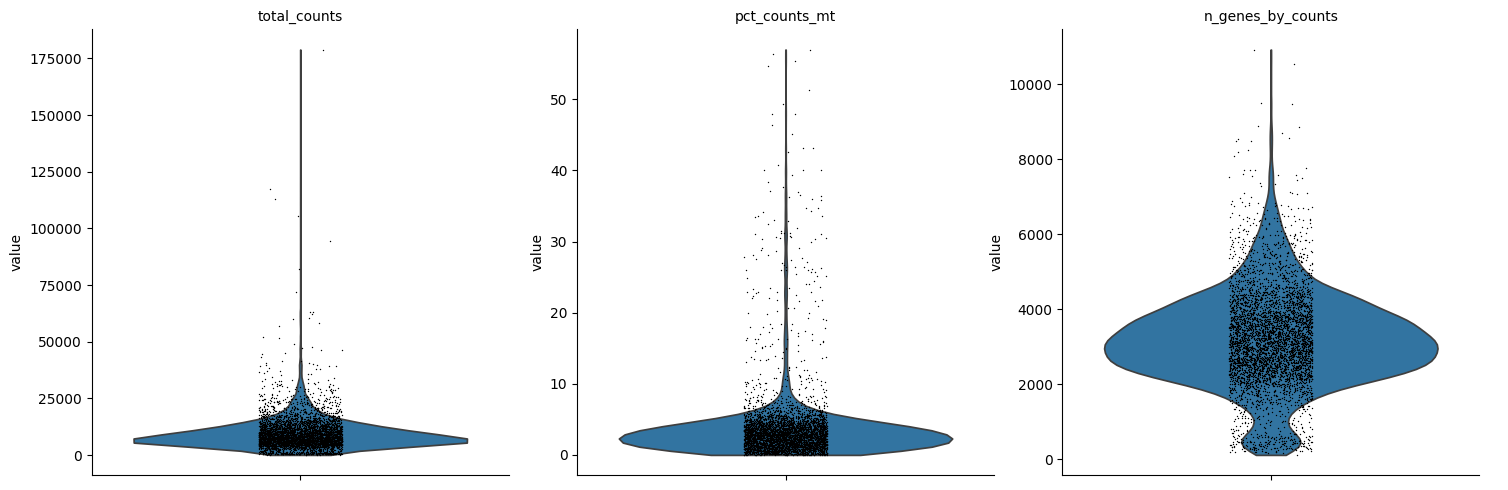

In [8]:
sc.pl.violin(rna, ["total_counts", "pct_counts_mt", "n_genes_by_counts"], multi_panel=True)

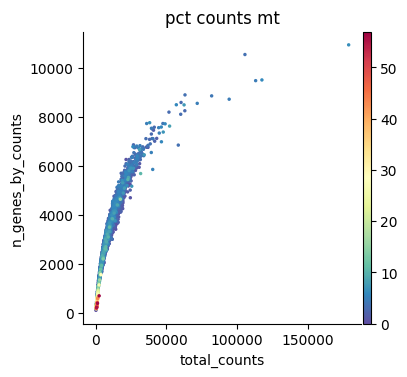

In [9]:
sc.pl.scatter(rna, x="total_counts", y="n_genes_by_counts", color="pct_counts_mt")

In [10]:
def _compute_outlier(adata: AnnData, metric: str, nmads: int):
    """Automated outlier detection in scRNA-seq data"""
    M = adata.obs[metric]
    outlier = (M < np.median(M) - nmads * median_abs_deviation(M)) | (
        np.median(M) + nmads * median_abs_deviation(M) < M
    )
    return outlier


rna.obs["outlier"] = (
    _compute_outlier(rna, "log1p_total_counts", 5)
    | _compute_outlier(rna, "log1p_n_genes_by_counts", 5)
    | (rna.obs["pct_counts_mt"] > 10)
)

Reading Fragments: 100%|██████████| 1000000/1000000 [00:01<00:00, 647834.99it/s]


<Axes: xlabel='nucleosome_signal', ylabel='Count'>

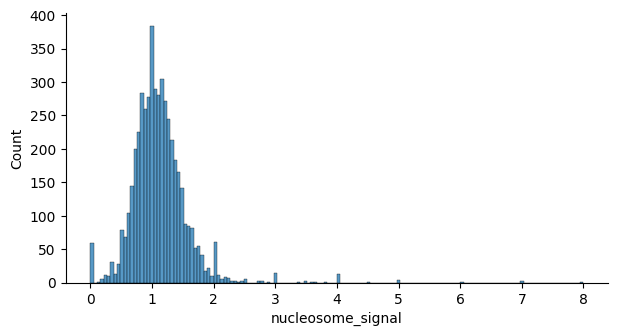

In [11]:
sc.pp.calculate_qc_metrics(atac, percent_top=None, log1p=False, inplace=True)
mu.atac.tl.nucleosome_signal(atac, n=1e6)
nuc_threshold = 2
atac.obs["nuc_filter"] = ["NUC_FAIL" if ns > nuc_threshold else "NUC_PASS" for ns in atac.obs["nucleosome_signal"]]

fig, axs = plt.subplots(figsize=(7, 3.5))
sns.histplot(atac.obs, x="nucleosome_signal", ax=axs)

Fetching Regions...: 100%|██████████| 2000/2000 [00:05<00:00, 363.09it/s]


Text(0.5, 1.0, 'Up to 99.5% percentile')

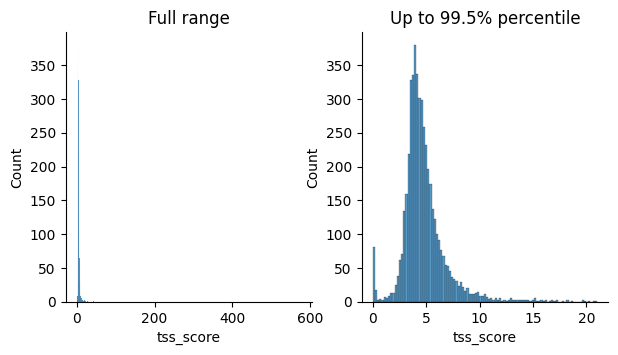

In [12]:
tss_enr = mu.atac.tl.tss_enrichment(atac, features=features, random_state=seed)
fig, axs = plt.subplots(1, 2, figsize=(7, 3.5))
p1 = sns.histplot(atac.obs, x="tss_score", ax=axs[0])
p1.set_title("Full range")
p2 = sns.histplot(
    atac.obs,
    x="tss_score",
    binrange=(0, atac.obs["tss_score"].quantile(0.995)),
    ax=axs[1],
)
p2.set_title("Up to 99.5% percentile")

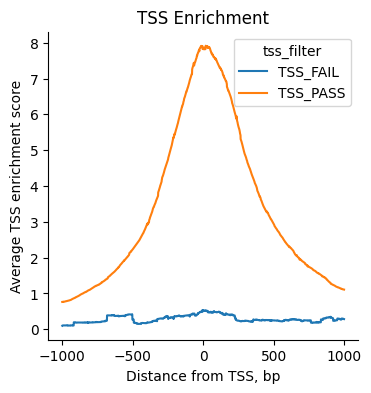

In [13]:
tss_threshold = 1.5
tss_enr.obs["tss_filter"] = ["TSS_FAIL" if score < tss_threshold else "TSS_PASS" for score in atac.obs["tss_score"]]
atac.obs["tss_filter"] = ["TSS_FAIL" if score < tss_threshold else "TSS_PASS" for score in atac.obs["tss_score"]]

fig, ax = plt.subplots()
mu.atac.pl.tss_enrichment(tss_enr, color="tss_filter", ax=ax)

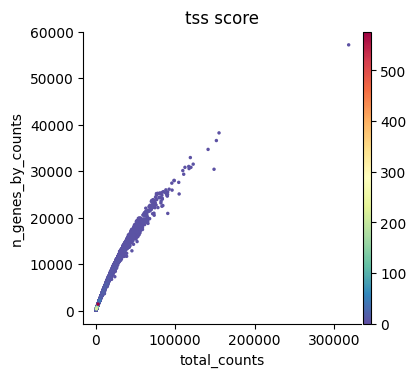

In [14]:
sc.pl.scatter(atac, x="total_counts", y="n_genes_by_counts", color="tss_score")

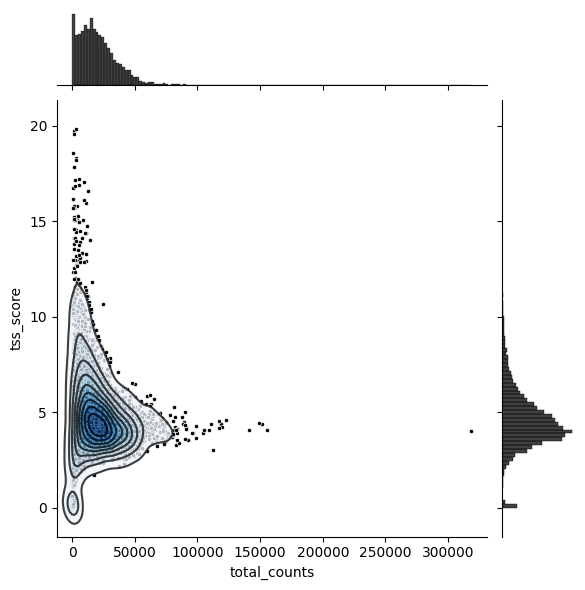

In [15]:
plot_tss_max = 20
g = sns.jointplot(
    data=atac[(atac.obs["tss_score"] < plot_tss_max)].obs,
    x="total_counts",
    y="tss_score",
    color="black",
    marker=".",
)
g.plot_joint(sns.kdeplot, fill=True, cmap="Blues", zorder=1, alpha=0.75)
g.plot_joint(sns.kdeplot, color="black", zorder=2, alpha=0.75)

In [16]:
atac.obs["outlier"] = (
    (atac.obs["tss_filter"] == "TSS_FAIL") | (atac.obs["tss_score"] > 15) | (atac.obs["nuc_filter"] == "NUC_FAIL")
)

In [17]:
data = MuData({"rna": rna, "atac": atac})
mask = ~(data.obs["rna:outlier"] | data.obs["atac:outlier"])
data = data[mask, :].copy()

annotations = pd.read_csv(annotation_path, sep="\t", header=0, index_col=0)
data.obs = data.obs.join(annotations)

non_developing_clusters = ["Cajal-Retzius", "Interneurons1", "Interneurons2", "Interneurons3", "Microglia", np.nan]
data = data[~data.obs["celltype"].isin(non_developing_clusters)].copy()

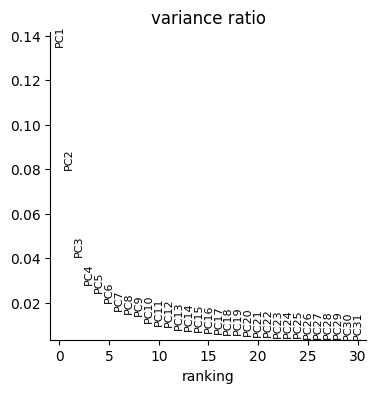

In [18]:
sc.pp.normalize_total(data["rna"])
sc.pp.log1p(data["rna"])
sc.pp.highly_variable_genes(data["rna"], n_top_genes=2000)
sc.pp.pca(data["rna"], random_state=seed)
sc.pl.pca_variance_ratio(data["rna"])

## ATLAS Preprocessing

We now obtained all the necessary data and structures to apply the ATLAS preprocessing function. This function automatically perfroms gene activity computation, normalization and dimensionality reduction, as well as the computation of single-modality KNNs and the WNN. 

The {func}``atlas.pp.preprocessing`` requires: 
1. Multiomics data into a {class}``muon.MuData`` object
2. Genomics coordinates
3. Path to the fragment file: since the file was previously located in the ``atac`` modality, we do not explicitly set it. 
4. Preprocessing parameters such as the number of PCs and neighbors for single-modality computations. We here chose to search for per-modality 15 neighbors and set the number of PCs to 20 and 10, respectively for gene expression and gene activity modalities. 
5. Parameters for the WNN construction: here we set the number of neighbors to the per-modality arithmentic mean by declaring ``wnn`` paramere equal to ``None``.

As a result, a separate MuData object containing cell metadata and the ``rna`` and ``activity`` modalities and intermodality structures is obtained. 


In [19]:
knn_rna, knn_act, wnn = 15, 15, None
n_pcs_rna, n_pcs_act = 20, 10

mudata = atlas.pp.preprocessing(
    mudata=data,
    n_pcs_rna=n_pcs_rna,
    n_pcs_act=n_pcs_act,
    knn_rna=knn_rna,
    knn_act=knn_act,
    n_neighbors=wnn,
    features=features,
)

mudata

100%|██████████| 32195/32195 [00:42<00:00, 755.07it/s] 
/Users/lrcq/atlasVenv/lib/python3.12/site-packages/mudata/_core/mudata.py:931: UserWarning: Cannot join columns with the same name because var_names are intersecting.
  warnings.warn(


MuData object with n_obs × n_vars = 3486 × 64480
  obs:	'atac:n_genes_by_counts', 'atac:total_counts', 'atac:nucleosome_signal', 'atac:nuc_filter', 'atac:tss_score', 'atac:tss_filter', 'atac:outlier', 'celltype'
  uns:	'wnn', 'umap'
  obsm:	'atac', 'X_umap'
  obsp:	'wnn_distances', 'wnn_connectivities'
  2 modalities
    rna:	3486 x 32285
      obs:	'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier'
      var:	'gene_ids', 'feature_types', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'log1p', 'hvg', 'pca', 'neighbors'
      obsm:	'X_pca'
      varm:	'PCs'
      obsp:	'distances', 'connectivities'
    activity:	3486 x 32195
      obs:	'n_genes_by_counts', 'total_counts', 'nucleosome_signal', 'nuc_filter', 'tss_score', 'tss_filter', 'outlier'
      var:	'Chromosome', 'Start', 'End'
      uns:	'pca', 'neighbors'
      obsm:	'X_pca'
      varm:	'PCs'
      obsp:	'distances', 'connectivities'

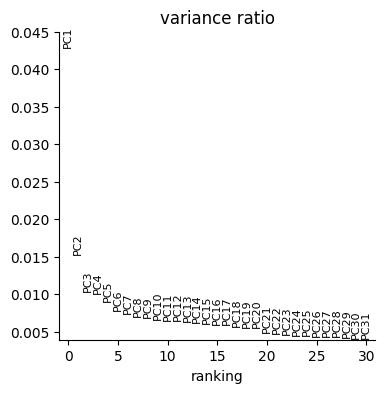

In [20]:
sc.pl.pca_variance_ratio(mudata["activity"])

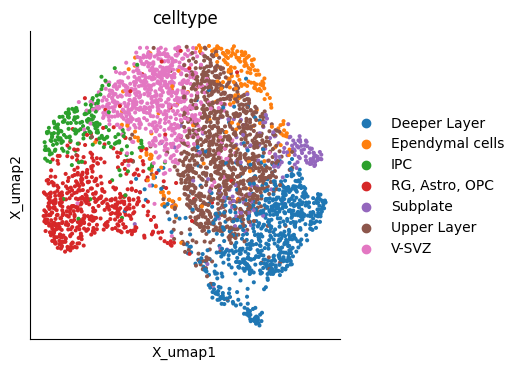

In [21]:
mu.pl.embedding(mudata, basis="X_umap", color=["celltype"])

In [22]:
mudata.write(os.path.join(data_path, "data.h5mu"))